In [59]:
import networkx as nx
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [60]:
import sys
import scipy

print(f"Python:     {sys.version.split()[0]}")
print(f"NetworkX:   {nx.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"SciPy:      {scipy.__version__}")
print(f"Pandas:     {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

Python:     3.11.15
NetworkX:   3.6.1
NumPy:      2.4.4
SciPy:      1.17.1
Pandas:     3.0.2
Matplotlib: 3.10.8


In [61]:
df = pd.read_csv("data/musae_git_edges.csv")
G = nx.from_pandas_edgelist(df, source="id_1", target="id_2")

In [62]:
print(f"node sayisi (N): {G.number_of_nodes()}")
print(f"edge sayisi (L): {G.number_of_edges()}")
print(f"ortalama derece <k>: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"yogunluk: {nx.density(G):.4f}")
print(f"geciskenlik: {nx.transitivity(G):.4f}")
print(f"bagli bilesen sayisi: {nx.number_connected_components(G)}")

node sayisi (N): 37700
edge sayisi (L): 289003
ortalama derece <k>: 15.33
yogunluk: 0.0004
geciskenlik: 0.0124
bagli bilesen sayisi: 1


## 4. DERECE DAĞILIMI ANALİZİ

In [63]:
import collections

***Gerçek Ağın Derece Dağılımı***

In [64]:
degrees = [d for _, d in G.degree()]
degree_count = collections.Counter(degrees)
deg_values = sorted(degree_count.keys())
deg_probs = [degree_count[k] / G.number_of_nodes() for k in deg_values]

***ER Rastgele Ağı***
* ``N = 37700``
* ``<k>= 15.33``

In [65]:
n = G.number_of_nodes()
p = (2 * G.number_of_edges()) / (n * (n - 1))  # baglanma olasiligi
ER = nx.erdos_renyi_graph(n, p, seed=42)
er_degrees = [d for _, d in ER.degree()]
er_count = collections.Counter(er_degrees)
er_values = sorted(er_count.keys())
er_probs = [er_count[k] / n for k in er_values]

***Lineer Ölçek -- Log-Log Ölçek***

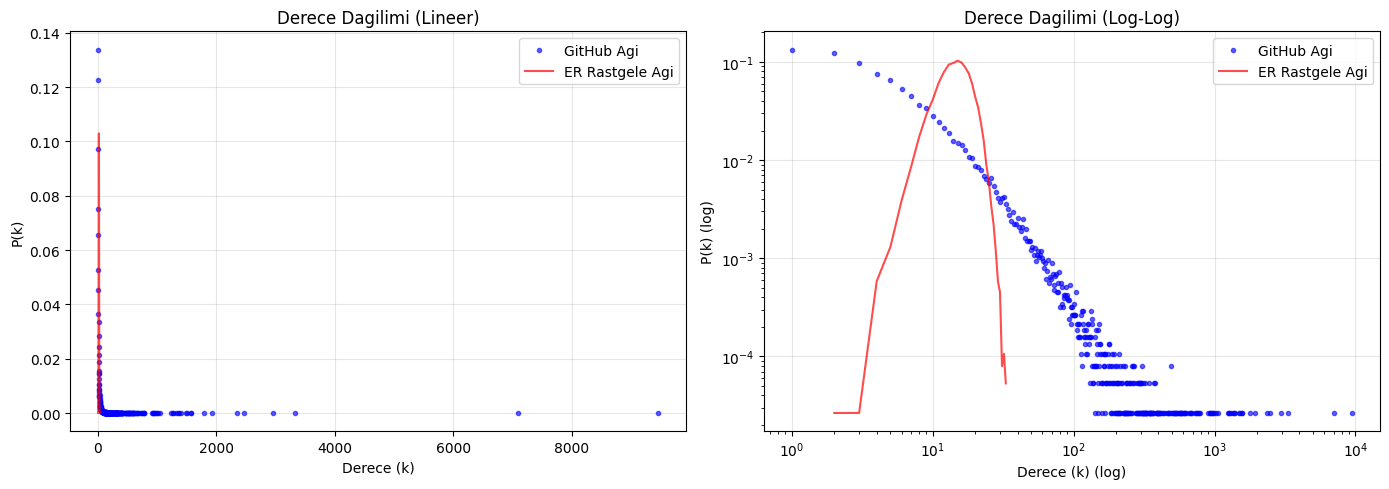

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deg_values, deg_probs, 'bo', markersize=3, alpha=0.6, label='GitHub Agi')
axes[0].plot(er_values, er_probs, 'r-', alpha=0.7, label='ER Rastgele Agi')
axes[0].set_xlabel('Derece (k)')
axes[0].set_ylabel('P(k)')
axes[0].set_title('Derece Dagilimi (Lineer)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].loglog(deg_values, deg_probs, 'bo', markersize=3, alpha=0.6, label='GitHub Agi')
axes[1].loglog(er_values, er_probs, 'r-', alpha=0.7, label='ER Rastgele Agi')
axes[1].set_xlabel('Derece (k) (log)')
axes[1].set_ylabel('P(k) (log)')
axes[1].set_title('Derece Dagilimi (Log-Log)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/derece_dagilimi.png", dpi=150, bbox_inches='tight')
plt.show()

***Temel Bilgiler***

In [67]:
print(f"\nGercek Ag - max derece: {max(degrees)}, min derece: {min(degrees)}")
print(f"ER Agi - max derece: {max(er_degrees)}, min derece: {min(er_degrees)}")


Gercek Ag - max derece: 9458, min derece: 1
ER Agi - max derece: 33, min derece: 2


γ (power law) ≈ 1.47
R² = 0.8258


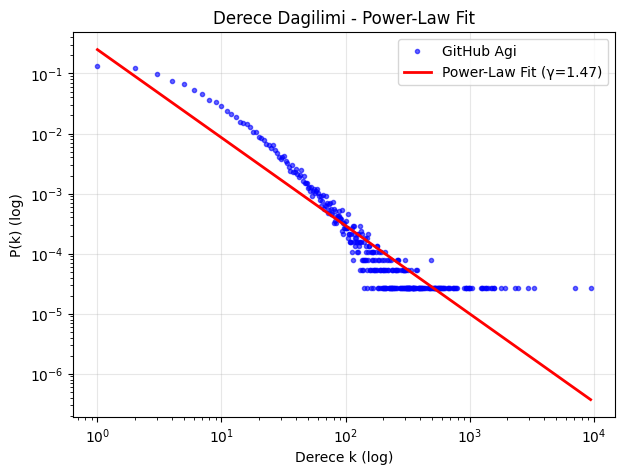

In [68]:
from scipy import stats

# sadece k >= 1 olan degerleri al
deg_vals = np.array(deg_values)
deg_p = np.array(deg_probs)

mask = (deg_vals > 0) & (deg_p > 0)
log_k = np.log(deg_vals[mask])
log_p = np.log(deg_p[mask])

# dogrusal fit (log-log'da duz cizgi = power law)
slope, intercept, r_value, p_value, std_err = stats.linregress(log_k, log_p)

print(f"γ (power law) ≈ {-slope:.2f}")
print(f"R² = {r_value**2:.4f}")

# fit cigisinin grafige eklenmesi
fit_line = np.exp(intercept + slope * log_k)

plt.figure(figsize=(7, 5))
plt.loglog(deg_vals[mask], deg_p[mask], 'bo', markersize=3, alpha=0.6, label='GitHub Agi')
plt.loglog(deg_vals[mask], fit_line, 'r-', linewidth=2, label=f'Power-Law Fit (γ={-slope:.2f})')
plt.xlabel('Derece k (log)')
plt.ylabel('P(k) (log)')
plt.title('Derece Dagilimi - Power-Law Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("figures/powerlaw_fit.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. MESAFE VE KÜÇÜK DÜNYA ANALİZİ

Tam ağda hesaplama çok uzun sürüyor *networkx* tek thread kullanıyor. Bu nedenle bilgisayarın GPU'sundan faydalanmıyor.

In [69]:
# avg_path = nx.average_shortest_path_length(G)

In [70]:
import random
import time

In [71]:
# 5000 rastgele kaynak dugumden ortalama yol uzunlugu
random.seed(42)
sample_nodes = random.sample(list(G.nodes()), 5000)

print(f"ornekleme basladi: {len(sample_nodes)} node")
start = time.time()

lengths = []
for i, node in enumerate(sample_nodes):
    path_lengths = nx.single_source_shortest_path_length(G, node)
    lengths.extend(path_lengths.values())
    if (i+1) % 500 == 0:
        elapsed = time.time() - start
        print(f"  {i+1}/5000 tamamlandi — {elapsed:.0f} saniye gecti")

# 0 (kendisine olan mesafe) cikar
lengths = [l for l in lengths if l > 0]

avg_path = np.mean(lengths)
max_path = max(lengths)

print(f"ortalama yol uzunlugu (ornekleme): {avg_path:.4f}")
print(f"maksimum mesafe (diameter tahmini): {max_path}")

ornekleme basladi: 5000 node
  500/5000 tamamlandi — 25 saniye gecti
  1000/5000 tamamlandi — 48 saniye gecti
  1500/5000 tamamlandi — 71 saniye gecti
  2000/5000 tamamlandi — 95 saniye gecti
  2500/5000 tamamlandi — 118 saniye gecti
  3000/5000 tamamlandi — 143 saniye gecti
  3500/5000 tamamlandi — 169 saniye gecti
  4000/5000 tamamlandi — 194 saniye gecti
  4500/5000 tamamlandi — 219 saniye gecti
  5000/5000 tamamlandi — 244 saniye gecti
ortalama yol uzunlugu (ornekleme): 3.2628
maksimum mesafe (diameter tahmini): 10


In [72]:
# ER agi icin de ayni hesaplamalar
er_sample = random.sample(list(ER.nodes()), 5000)
er_lengths = []
for node in er_sample:
    pl = nx.single_source_shortest_path_length(ER, node)
    er_lengths.extend(pl.values())
er_lengths = [l for l in er_lengths if l > 0]

print(f"\nER - ortalama yol uzunlugu: {np.mean(er_lengths):.4f}")
print(f"ER - maksimum mesafe: {max(er_lengths)}")


ER - ortalama yol uzunlugu: 4.1406
ER - maksimum mesafe: 6


In [73]:
from collections import Counter

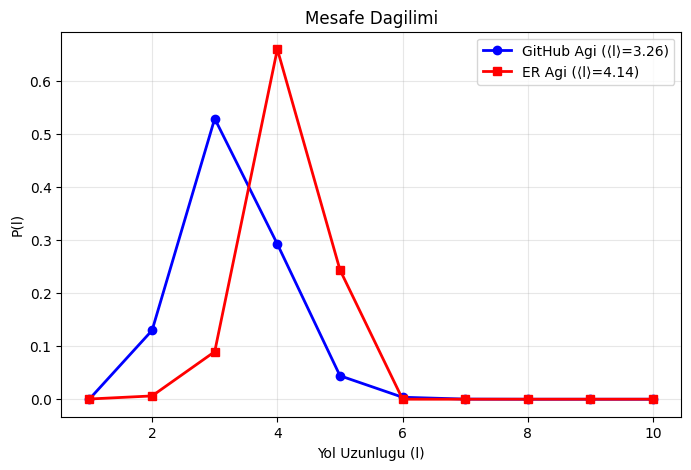

In [74]:
# mesafe dagilimi grafigi
len_count = Counter(lengths)
er_len_count = Counter(er_lengths)

all_dists = sorted(set(lengths) | set(er_lengths))

git_probs = [len_count.get(d, 0) / len(lengths) for d in all_dists]
er_probs_dist = [er_len_count.get(d, 0) / len(er_lengths) for d in all_dists]

plt.figure(figsize=(8, 5))
plt.plot(all_dists, git_probs, 'bo-', label=f'GitHub Agi (⟨l⟩={avg_path:.2f})', linewidth=2)
plt.plot(all_dists, er_probs_dist, 'rs-', label=f'ER Agi (⟨l⟩={np.mean(er_lengths):.2f})', linewidth=2)
plt.xlabel('Yol Uzunlugu (l)')
plt.ylabel('P(l)')
plt.title('Mesafe Dagilimi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("figures/mesafe_dagilimi.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. DERECE KORELASYONLARI

In [75]:
# assortativity katsayisi
r = nx.degree_assortativity_coefficient(G)
print(f"Assortativity katsayisi (r): {r:.4f}")

# k_nn(k): ortalama komsu derecesi
knn = nx.average_neighbor_degree(G)

Assortativity katsayisi (r): -0.0752


In [76]:
# k degerlerine gore gruplama yap
from collections import defaultdict
knn_by_degree = defaultdict(list)
for node, avg_neighbor_deg in knn.items():
    k = G.degree(node)
    knn_by_degree[k].append(avg_neighbor_deg)

# her k icin ortalama al
k_vals = sorted(knn_by_degree.keys())
knn_vals = [np.mean(knn_by_degree[k]) for k in k_vals]

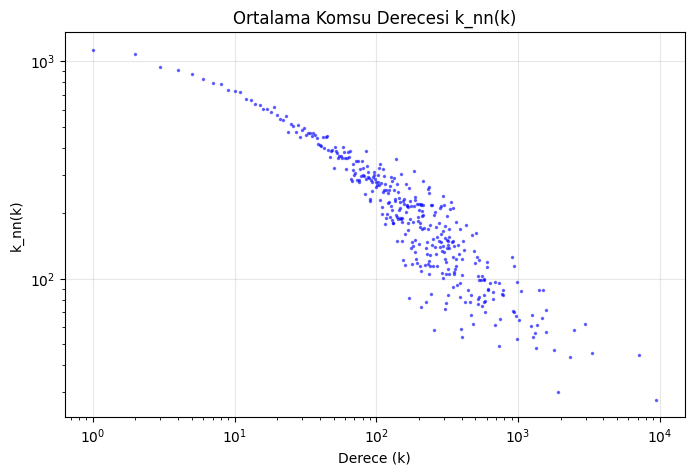

In [77]:
# grafik
plt.figure(figsize=(8, 5))
plt.plot(k_vals, knn_vals, 'b.', alpha=0.5, markersize=3)
plt.xlabel('Derece (k)')
plt.ylabel('k_nn(k)')
plt.title('Ortalama Komsu Derecesi k_nn(k)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.savefig("figures/knn.png", dpi=150, bbox_inches='tight')
plt.show()

In [78]:
print(f"\nr > 0 → assortative (yuksek dereceli node'lari birbirine baglanir)")
print(f"r < 0 → disassortative (yuksek dereceli node'lari dusuk dereceli olanlara baglanir)")
print(f"r = 0 → notr")
print(f"\nGitHub Agi: r = {r:.4f}")


r > 0 → assortative (yuksek dereceli node'lari birbirine baglanir)
r < 0 → disassortative (yuksek dereceli node'lari dusuk dereceli olanlara baglanir)
r = 0 → notr

GitHub Agi: r = -0.0752


In [79]:
# eij matrisi hesaplama
degrees = dict(G.degree())
max_degree = max(degrees.values())

In [80]:
# eij: kenar uclarinin derece ciftlerinin olasilik matrisi
from collections import defaultdict
edge_pairs = defaultdict(int)
total_edges = G.number_of_edges()

for u, v in G.edges():
    ki = degrees[u]
    kj = degrees[v]
    edge_pairs[(ki, kj)] += 1
    edge_pairs[(kj, ki)] += 1  # yonsuz ag

# normalize etme
eij = {pair: count / (2 * total_edges) for pair, count in edge_pairs.items()}

# en sik gorulen 10 derece cifti
top_pairs = sorted(eij.items(), key=lambda x: x[1], reverse=True)[:10]
print("En sık görülen derece çiftleri (ki, kj) → P(eij):")
for (ki, kj), prob in top_pairs:
    print(f"  ({ki:4d}, {kj:4d}) → {prob:.6f}")

En sık görülen derece çiftleri (ki, kj) → P(eij):
  (9458,    2) → 0.001024
  (   2, 9458) → 0.001024
  (9458,    3) → 0.000974
  (   3, 9458) → 0.000974
  (9458,    4) → 0.000957
  (   4, 9458) → 0.000957
  (9458,    5) → 0.000919
  (   5, 9458) → 0.000919
  (   6, 9458) → 0.000822
  (9458,    6) → 0.000822


In [81]:
# eij'den r hesapla (manuel, NetworkX ile teyit ederiz)
# r = [Σ_ij (ki*kj*eij) - μ²] / σ²
numerator = sum(ki * kj * p for (ki, kj), p in eij.items())
q_k = {}  # kenar ucu derece dagilimi
for (ki, kj), p in eij.items():
    q_k[ki] = q_k.get(ki, 0) + p
mu = sum(k * q for k, q in q_k.items())
sigma2 = sum(k**2 * q for k, q in q_k.items()) - mu**2

r_manual = (numerator - mu**2) / sigma2

In [82]:
print(f"\nManuel hesaplanan r: {r_manual:.4f}")
print(f"NetworkX r: {r:.4f}")  # teyit


Manuel hesaplanan r: -0.0752
NetworkX r: -0.0752


In [83]:
# Xulvi-Brunet & Sokolov Algoritmasi
def xulvi_brunet_sokolov(G, assortative=True, steps=50000):
    """
    assortative=True  → yuksek dereceli node'lari birbirine bagla
    assortative=False → yuksek ile dusuk node'lari dugummleri bagla
    """
    H = G.copy()
    edges = list(H.edges())
    
    for _ in range(steps):
        # rastgele iki kenar secme
        if len(edges) < 2:
            break
        idx1, idx2 = random.sample(range(len(edges)), 2)
        u, v = edges[idx1]
        s, t = edges[idx2]
        
        # 4 node'un hepsi farkli olmali
        if len({u, v, s, t}) < 4:
            continue
        
        degrees = [H.degree(u), H.degree(v), H.degree(s), H.degree(t)]
        nodes = [u, v, s, t]
        sorted_nodes = [x for _, x in sorted(zip(degrees, nodes), reverse=True)]
        
        if assortative:
            # en yuksek iki node birbirine, en dusuk iki node birbirine
            new_e1 = (sorted_nodes[0], sorted_nodes[1])
            new_e2 = (sorted_nodes[2], sorted_nodes[3])
        else:
            # en yuksek ile en dusuk, ortadakiler
            new_e1 = (sorted_nodes[0], sorted_nodes[3])
            new_e2 = (sorted_nodes[1], sorted_nodes[2])
        
        # kontrol
        if (new_e1[0] == new_e1[1] or new_e2[0] == new_e2[1]):
            continue
        if H.has_edge(*new_e1) or H.has_edge(*new_e2):
            continue
        
        # eski edgeleri sil, yenileri koy
        H.remove_edge(u, v)
        H.remove_edge(s, t)
        H.add_edge(*new_e1)
        H.add_edge(*new_e2)
        edges[idx1] = new_e1
        edges[idx2] = new_e2
    
    return H

In [84]:
# Assortative Ag
print("Assortative ag uretiliyor...")
G_assort = xulvi_brunet_sokolov(G, assortative=True, steps=5000000)
r_assort = nx.degree_assortativity_coefficient(G_assort)
print(f"Assortative ag r = {r_assort:.4f}")

Assortative ag uretiliyor...
Assortative ag r = -0.0593


In [85]:
# Disassortative Ag
print("Disassortative ag uretiliyor...")
G_disassort = xulvi_brunet_sokolov(G, assortative=False, steps=5000000)
r_disassort = nx.degree_assortativity_coefficient(G_disassort)
print(f"Disassortative ag r = {r_disassort:.4f}")

Disassortative ag uretiliyor...
Disassortative ag r = -0.0883


In [86]:
print(f"\nGitHub agi r = {r:.4f}")
print(f"Assortative ağ r = {r_assort:.4f}")
print(f"Disassortative ağ r = {r_disassort:.4f}")


GitHub agi r = -0.0752
Assortative ağ r = -0.0593
Disassortative ağ r = -0.0883


## 7. GÜRBÜZLÜK ANALİZİ

In [87]:
def robustness_analysis(G, attack_type='random', steps=100):
    """
    attack_type = 'random'  → rastgele düğüm sil
    attack_type = 'targeted' → en yüksek dereceli düğümü sil
    """
    H = G.copy()
    n = H.number_of_nodes()
    
    giant_sizes = [1.0]  # baslangic
    fractions = [0.0]
    
    step_size = n // steps
    
    for i in range(steps):
        if H.number_of_nodes() == 0:
            break
            
        # silinecek dugumleri secme
        if attack_type == 'random':
            nodes_to_remove = random.sample(list(H.nodes()), min(step_size, H.number_of_nodes()))
        else:  # targeted
            sorted_nodes = sorted(H.degree(), key=lambda x: x[1], reverse=True)
            nodes_to_remove = [n for n, _ in sorted_nodes[:step_size]]
        
        H.remove_nodes_from(nodes_to_remove)
        
        if H.number_of_nodes() == 0:
            giant_sizes.append(0)
        else:
            largest_cc = max(nx.connected_components(H), key=len)
            giant_sizes.append(len(largest_cc) / n)
        
        fractions.append((i + 1) * step_size / n)
    
    return fractions, giant_sizes

In [88]:
print("Rastgele saldiri hesaplaniyor...")
f_random, g_random = robustness_analysis(G, attack_type='random', steps=100)

print("Hedefli saldiri hesaplaniyor...")
f_targeted, g_targeted = robustness_analysis(G, attack_type='targeted', steps=100)

# ER agi icin karsilastirma
print("ER rastgele saldiri...")
f_er_random, g_er_random = robustness_analysis(ER, attack_type='random', steps=100)
print("ER hedefli saldiri...")
f_er_targeted, g_er_targeted = robustness_analysis(ER, attack_type='targeted', steps=100)

Rastgele saldiri hesaplaniyor...
Hedefli saldiri hesaplaniyor...
ER rastgele saldiri...
ER hedefli saldiri...


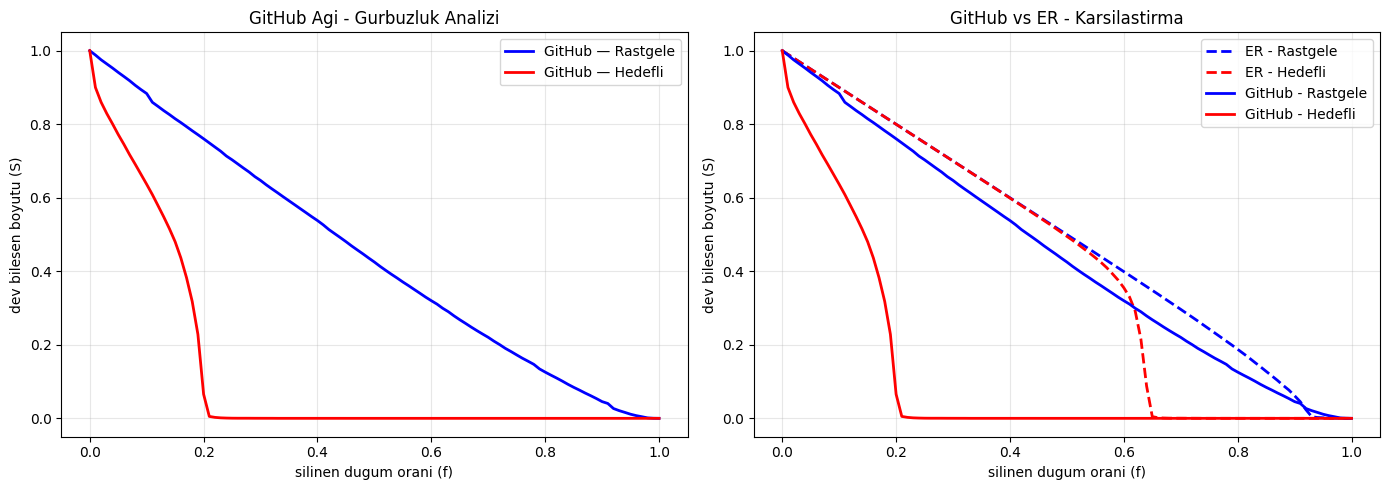

In [89]:
# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(f_random, g_random, 'b-', linewidth=2, label='GitHub — Rastgele')
axes[0].plot(f_targeted, g_targeted, 'r-', linewidth=2, label='GitHub — Hedefli')
axes[0].set_xlabel('silinen dugum orani (f)')
axes[0].set_ylabel('dev bilesen boyutu (S)')
axes[0].set_title('GitHub Agi - Gurbuzluk Analizi')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_er_random, g_er_random, 'b--', linewidth=2, label='ER - Rastgele')
axes[1].plot(f_er_targeted, g_er_targeted, 'r--', linewidth=2, label='ER - Hedefli')
axes[1].plot(f_random, g_random, 'b-', linewidth=2, label='GitHub - Rastgele')
axes[1].plot(f_targeted, g_targeted, 'r-', linewidth=2, label='GitHub - Hedefli')
axes[1].set_xlabel('silinen dugum orani (f)')
axes[1].set_ylabel('dev bilesen boyutu (S)')
axes[1].set_title('GitHub vs ER - Karsilastirma')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/gurbuzluk.png", dpi=150, bbox_inches='tight')
plt.show()

In [90]:
# kritik esik: dev bilesenin %1'e dustugu nokta
def find_critical_threshold(fractions, giant_sizes, threshold=0.01):
    for f, s in zip(fractions, giant_sizes):
        if s <= threshold:
            return f
    return 1.0

In [91]:
fc_random = find_critical_threshold(f_random, g_random)
fc_targeted = find_critical_threshold(f_targeted, g_targeted)

In [92]:
print(f"\nKritik Esikler")
print(f"GitHub - Rastgele saldiri: f_c = {fc_random:.2f}")
print(f"GitHub - Hedefli saldiri: f_c = {fc_targeted:.2f}")


Kritik Esikler
GitHub - Rastgele saldiri: f_c = 0.96
GitHub - Hedefli saldiri: f_c = 0.21


## 8. TOPLULUK ANALİZİ

In [93]:
import community as community_louvain

In [94]:
# Louvain community detection
partition = community_louvain.best_partition(G, random_state=42)

# Modularity degeri
modularity = community_louvain.modularity(partition, G)
print(f"modularity: {modularity:.4f}")

# Kac topluluk var
num_communities = len(set(partition.values()))
print(f"topluluk sayisi: {num_communities}")

modularity: 0.4534
topluluk sayisi: 31


In [95]:
# Topluluk boyutlari
from collections import Counter
community_sizes = Counter(partition.values())
sizes = sorted(community_sizes.values(), reverse=True)
print(f"\nEn buyuk 5 topluluk boyutu: {sizes[:5]}")
print(f"En kucuk 5 topluluk boyutu: {sizes[-5:]}")
print(f"Ortalama topluluk boyutu: {np.mean(sizes):.1f}")


En buyuk 5 topluluk boyutu: [8732, 7664, 6454, 3047, 2702]
En kucuk 5 topluluk boyutu: [3, 3, 3, 3, 3]
Ortalama topluluk boyutu: 1216.1


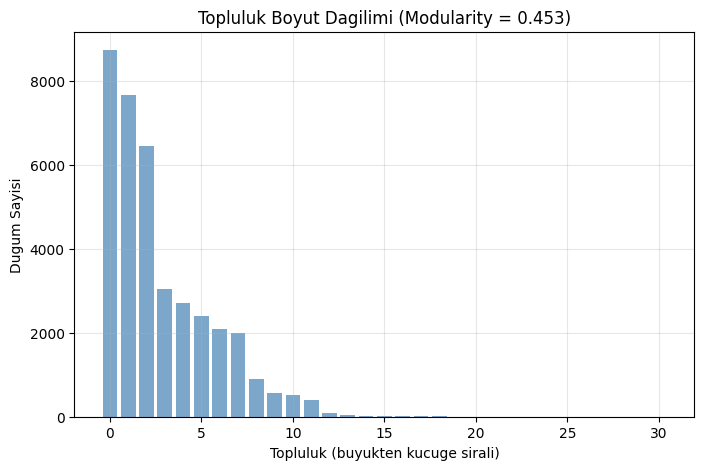

In [96]:
# Topluluk boyutu dagilimi grafigi
plt.figure(figsize=(8, 5))
plt.bar(range(len(sizes)), sizes, color='steelblue', alpha=0.7)
plt.xlabel('Topluluk (buyukten kucuge sirali)')
plt.ylabel('Dugum Sayisi')
plt.title(f'Topluluk Boyut Dagilimi (Modularity = {modularity:.3f})')
plt.grid(True, alpha=0.3)
plt.savefig("figures/community_sizes.png", dpi=150, bbox_inches='tight')
plt.show()

In [97]:
# target.csv ile topluluk karsilastirmasi
df_target = pd.read_csv("data/musae_git_target.csv")

# Her topluluktaki web/ML developer orani
df_target['community'] = df_target['id'].map(partition)

community_composition = df_target.groupby('community')['ml_target'].agg(['sum', 'count'])
community_composition['ml_ratio'] = community_composition['sum'] / community_composition['count']
community_composition['web_ratio'] = 1 - community_composition['ml_ratio']
community_composition = community_composition.sort_values('count', ascending=False)

print("En buyuk 10 topluluk:")
print(f"{'Topluluk':>10} {'Boyut':>8} {'ML Dev %':>10} {'Web Dev %':>10}")
print("-" * 42)
for comm, row in community_composition.head(10).iterrows():
    print(f"{comm:>10} {int(row['count']):>8} {row['ml_ratio']*100:>9.1f}% {row['web_ratio']*100:>9.1f}%")

En buyuk 10 topluluk:
  Topluluk    Boyut   ML Dev %  Web Dev %
------------------------------------------
         7     8732       6.5%      93.5%
         2     7664      71.5%      28.5%
        13     6454      19.4%      80.6%
         0     3047      15.1%      84.9%
         5     2702       6.2%      93.8%
        11     2396      27.0%      73.0%
         8     2087       8.9%      91.1%
         3     2000      21.9%      78.1%
         4      904      28.2%      71.8%
        10      566      16.6%      83.4%


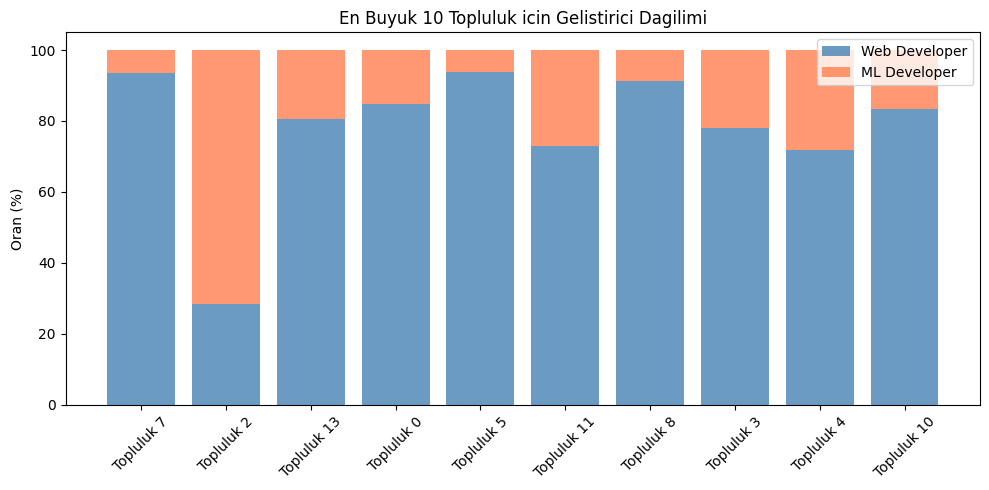

In [98]:
# Grafik — ML/Web orani vs topluluk boyutu
plt.figure(figsize=(10, 5))
top10 = community_composition.head(10)
x = range(len(top10))
plt.bar(x, top10['web_ratio']*100, label='Web Developer', color='steelblue', alpha=0.8)
plt.bar(x, top10['ml_ratio']*100, bottom=top10['web_ratio']*100, 
        label='ML Developer', color='coral', alpha=0.8)
plt.xticks(x, [f"Topluluk {i}" for i in top10.index], rotation=45)
plt.ylabel('Oran (%)')
plt.title('En Buyuk 10 Topluluk icin Gelistirici Dagilimi')
plt.legend()
plt.tight_layout()
plt.savefig("figures/community_composition.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. GENEL DEĞERLENDİRME VE SONUÇ

In [99]:
# BA modeli: her yeni dugum L tane kenar ekler
# Ortalama derece = 2L -> L = ⟨k⟩/2 = 15.33/2 ~ 8
L_BA = round(sum(dict(G.degree()).values()) / (2 * G.number_of_nodes()))
print(f"BA modeli icin m = {L_BA}")

BA = nx.barabasi_albert_graph(n=G.number_of_nodes(), m=L_BA, seed=42)

# Karsilastirma
r_ba = nx.degree_assortativity_coefficient(BA)
print(f"\nGercek ag - max derece: {max(dict(G.degree()).values())}, r: {r:.4f}")
print(f"BA modeli - max derece: {max(dict(BA.degree()).values())}, r: {r_ba:.4f}")
print(f"ER modeli - max derece: {max(dict(ER.degree()).values())}, r: {nx.degree_assortativity_coefficient(ER):.4f}")

BA modeli icin m = 8

Gercek ag - max derece: 9458, r: -0.0752
BA modeli - max derece: 891, r: -0.0138
ER modeli - max derece: 33, r: -0.0024


In [100]:
from scipy.ndimage import uniform_filter1d

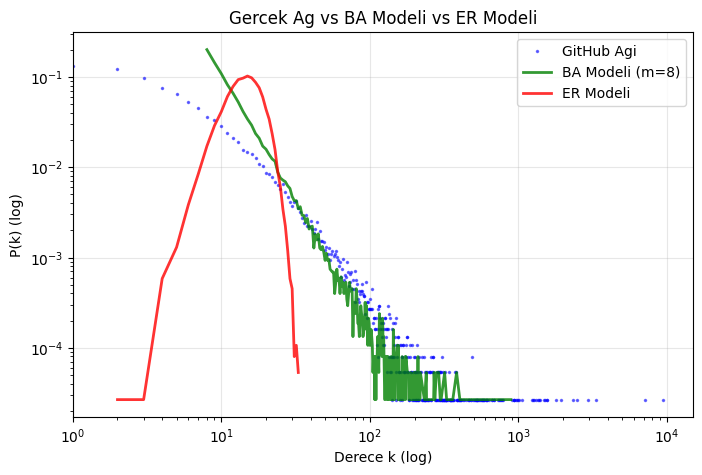

In [101]:
# BA dagilimini duzlestirme
ba_degrees = [d for _, d in BA.degree()]
ba_count = Counter(ba_degrees)
ba_vals = sorted(ba_count.keys())
ba_probs_raw = np.array([ba_count[k] / BA.number_of_nodes() for k in ba_vals])

plt.figure(figsize=(8, 5))
plt.loglog(deg_values, deg_probs, 'b.', alpha=0.5, markersize=3, label='GitHub Agi')
plt.loglog(ba_vals, ba_probs_raw, 'g-', linewidth=2, alpha=0.8, label=f'BA Modeli (m={L_BA})')
plt.loglog(er_values, er_probs, 'r-', linewidth=2, alpha=0.8, label='ER Modeli')
plt.xlabel('Derece k (log)')
plt.ylabel('P(k) (log)')
plt.title('Gercek Ag vs BA Modeli vs ER Modeli')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(left=1)
plt.savefig("figures/model_karsilastirma.png", dpi=150, bbox_inches='tight')
plt.show()

***Gephi'de Ağ Görselini Oluşturmak İçin***

In [102]:
# Gephi icin GEXF formatinda kaydet
nx.write_gexf(G, "data/github_network.gexf")

In [103]:
# Sadece yuksek dereceli dugumleri al (derece > 50)
high_degree_nodes = [n for n, d in G.degree() if d > 50]
subG = G.subgraph(high_degree_nodes)

print(f"Alt ağ: {subG.number_of_nodes()} node, {subG.number_of_edges()} edge")

# GEXF olarak kaydet
nx.write_gexf(subG, "data/github_subnetwork.gexf")

Alt ağ: 1844 node, 48424 edge


In [104]:
print(f"Louvain: {community_louvain.__version__}")

Louvain: 0.16
